# Data Generation

To evaluate forecasting and inventory optimization techniques under realistic supply chain conditions, a synthetic dataset will be generated covering the period from January 2020 through December 2025. For simplicity, the effects of the COVID-19 pandemic will be ignored, and the simulated environment will assume stable market conditions throughout the entire period.

The dataset will contain the following fields:

| Column            | Description                                 |
| ----------------- | ------------------------------------------- |
| date              | Observation date                            |
| sku_id            | Unique product identifier                   |
| category          | Product category                            |
| demand_type       | Demand behavior assigned to the SKU         |
| sales             | Units sold during the day                   |
| inventory_end     | Inventory level at the end of the day       |
| replenishment_qty | Quantity received from replenishment orders |
| stockout_flag     | Indicates whether a stockout occurred       |

The data generation process starts by assigning each SKU to a predefined demand profile. Daily sales are then simulated over time while an inventory policy controls replenishment decisions and inventory availability.

A continuous review inventory policy will be used throughout the simulation. Each SKU starts with an initial inventory level and a fixed lead time. Whenever inventory falls below a predefined reorder point, a replenishment order is triggered. After the lead time elapses, the ordered quantity is added to inventory. Daily sales consume available inventory, and stockout events occur whenever inventory is insufficient to satisfy customer demand.

This mechanism creates a realistic environment in which stockouts naturally emerge, causing sales observations to become censored representations of actual customer demand. The resulting dataset will serve as the foundation for demand segmentation, forecasting model development, inventory policy optimization, and business impact simulation.

### Group 1 generator design


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt


def generate_group1_skus(rng=None):
    """
    Generate steady-demand SKUs with correlated demand patterns and one
    inventory policy per SKU.

    Returns
    -------
    pd.DataFrame
        Simulated daily SKU-level dataset from 2020 to 2025.
    """

    if rng is None:
        rng = np.random.default_rng(42)

    dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="D")
    sku_ids = [1, 2, 3, 4, 5]

    demand_type = "steady"
    category = "group_1_steady"

    records = []

    shared_noise = rng.normal(loc=0, scale=1, size=len(dates))

    for sku_id in sku_ids:

        base_demand = int(rng.integers(20, 60))

        lead_time = int(rng.integers(3, 8))
        safety_stock = int(base_demand * lead_time * rng.uniform(0.20, 0.40))
        reorder_point = int(base_demand * lead_time + safety_stock)
        order_up_to_level = int(base_demand * (lead_time + 7) + safety_stock)

        initial_inventory = int(order_up_to_level * rng.uniform(0.80, 1.10))
        inventory = initial_inventory

        pending_orders = []

        for t, date in enumerate(dates):

            replenishment_qty = 0
            received_orders = []

            for arrival_date, qty in pending_orders:
                if arrival_date <= date:
                    replenishment_qty += qty
                    inventory += qty
                    received_orders.append((arrival_date, qty))

            pending_orders = [
                order for order in pending_orders
                if order not in received_orders
            ]

            sku_noise = rng.normal(loc=0, scale=base_demand * 0.10)
            correlated_component = shared_noise[t] * base_demand * 0.15

            true_demand = base_demand + correlated_component + sku_noise
            true_demand = max(0, int(round(true_demand)))

            sales = min(true_demand, inventory)
            inventory -= sales

            stockout_flag = int(sales < true_demand)

            inventory_position = inventory + sum(qty for _, qty in pending_orders)

            if inventory_position <= reorder_point:
                order_qty = int(max(order_up_to_level - inventory_position, 0))
                arrival_date = date + pd.Timedelta(days=lead_time)
                pending_orders.append((arrival_date, order_qty))

            records.append({
                "date": date,
                "sku_id": sku_id,
                "category": category,
                "demand_type": demand_type,
                "sales": sales,
                "inventory_end": inventory,
                "replenishment_qty": replenishment_qty,
                "stockout_flag": stockout_flag,
                "base_demand": base_demand,
                "lead_time": lead_time,
                "safety_stock": safety_stock,
                "reorder_point": reorder_point,
                "order_up_to_level": order_up_to_level,
                "initial_inventory": initial_inventory
            })

    return pd.DataFrame(records)


rng = np.random.default_rng(42)

df_1 = generate_group1_skus(rng)
df_1.head()

,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory
0,2020-01-01,1,group_1_steady,steady,33,384,0,0,38,4,38,190,456,417
1,2020-01-02,1,group_1_steady,steady,31,353,0,0,38,4,38,190,456,417
2,2020-01-03,1,group_1_steady,steady,42,311,0,0,38,4,38,190,456,417
3,2020-01-04,1,group_1_steady,steady,43,268,0,0,38,4,38,190,456,417
4,2020-01-05,1,group_1_steady,steady,24,244,0,0,38,4,38,190,456,417


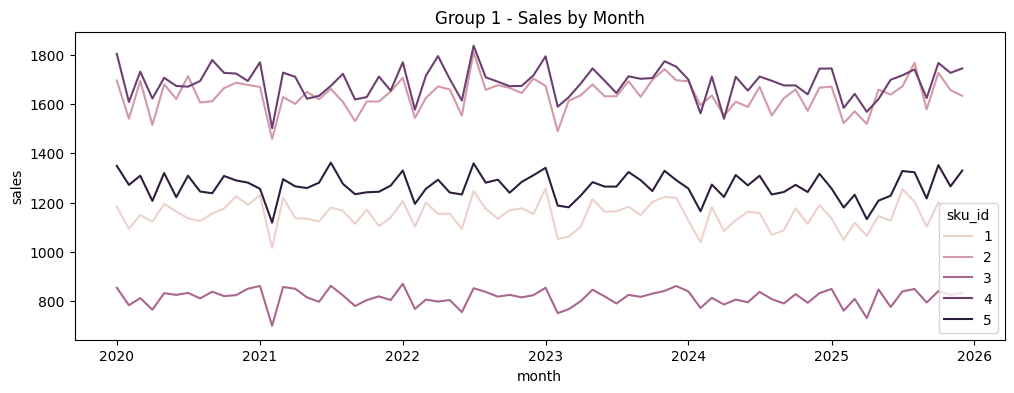

In [2]:

fig, ax = plt.subplots(figsize=(12,4))

df_month = (
    df_1
    .assign(month=df_1["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "sku_id"], as_index=False)["sales"]
    .sum()
)

sns.lineplot(
    data=df_month,
    x="month",
    y="sales",
    hue="sku_id"
)

plt.title('Group 1 - Sales by Month')
plt.show()

### Group 2 generator design

In [3]:
def generate_group2_skus(rng=None):
    """
    Generate seasonal-demand SKUs with correlated quarterly demand patterns
    and one inventory policy per SKU.

    Returns
    -------
    pd.DataFrame
        Simulated daily SKU-level dataset from 2020 to 2025.
    """

    if rng is None:
        rng = np.random.default_rng(42)

    dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="D")
    sku_ids = [6, 7, 8, 9, 10]

    demand_type = "seasonal"
    category = "group_2_seasonal"

    records = []

    shared_noise = rng.normal(loc=0, scale=1, size=len(dates))

    day_of_quarter = pd.Series(dates).dt.dayofyear.values % 91
    quarter_position = day_of_quarter / 90

    seasonal_curve = np.where(
        quarter_position <= 0.5,
        quarter_position / 0.5,
        (1 - quarter_position) / 0.5
    )

    for sku_id in sku_ids:

        base_demand = int(rng.integers(20, 70))
        seasonal_amplitude = rng.uniform(0.30, 0.80)

        lead_time = int(rng.integers(3, 8))

        average_expected_demand = base_demand * (1 + seasonal_amplitude * 0.50)

        safety_stock = int(
            average_expected_demand * lead_time * rng.uniform(0.20, 0.40)
        )

        reorder_point = int(
            average_expected_demand * lead_time + safety_stock
        )

        order_up_to_level = int(
            average_expected_demand * (lead_time + 7) + safety_stock
        )

        initial_inventory = int(order_up_to_level * rng.uniform(0.80, 1.10))
        inventory = initial_inventory

        pending_orders = []

        for t, date in enumerate(dates):

            replenishment_qty = 0
            received_orders = []

            for arrival_date, qty in pending_orders:
                if arrival_date <= date:
                    replenishment_qty += qty
                    inventory += qty
                    received_orders.append((arrival_date, qty))

            pending_orders = [
                order for order in pending_orders
                if order not in received_orders
            ]

            seasonal_multiplier = 1 + seasonal_amplitude * seasonal_curve[t]

            sku_noise = rng.normal(
                loc=0,
                scale=base_demand * 0.12
            )

            correlated_component = shared_noise[t] * base_demand * 0.15

            true_demand = (
                base_demand * seasonal_multiplier
                + correlated_component
                + sku_noise
            )

            true_demand = max(0, int(round(true_demand)))

            sales = min(true_demand, inventory)
            inventory -= sales

            stockout_flag = int(sales < true_demand)

            inventory_position = inventory + sum(qty for _, qty in pending_orders)

            if inventory_position <= reorder_point:
                order_qty = int(max(order_up_to_level - inventory_position, 0))
                arrival_date = date + pd.Timedelta(days=lead_time)
                pending_orders.append((arrival_date, order_qty))

            records.append({
                "date": date,
                "sku_id": sku_id,
                "category": category,
                "demand_type": demand_type,
                "sales": sales,
                "inventory_end": inventory,
                "replenishment_qty": replenishment_qty,
                "stockout_flag": stockout_flag,
                "base_demand": base_demand,
                "lead_time": lead_time,
                "safety_stock": safety_stock,
                "reorder_point": reorder_point,
                "order_up_to_level": order_up_to_level,
                "initial_inventory": initial_inventory
            })

    return pd.DataFrame(records)


df_2 = generate_group2_skus(rng)
df_2.head()

,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory
0,2020-01-01,6,group_2_seasonal,seasonal,26,367,0,0,22,5,43,184,383,393
1,2020-01-02,6,group_2_seasonal,seasonal,20,347,0,0,22,5,43,184,383,393
2,2020-01-03,6,group_2_seasonal,seasonal,30,317,0,0,22,5,43,184,383,393
3,2020-01-04,6,group_2_seasonal,seasonal,25,292,0,0,22,5,43,184,383,393
4,2020-01-05,6,group_2_seasonal,seasonal,26,266,0,0,22,5,43,184,383,393


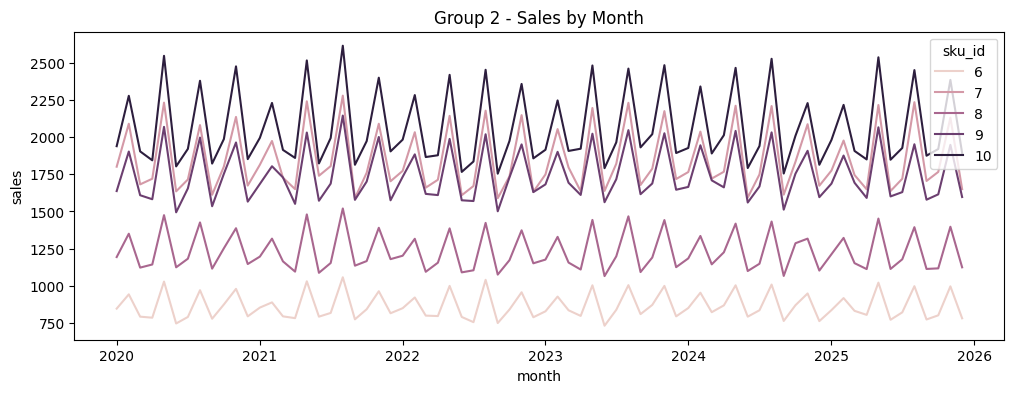

In [4]:

fig, ax = plt.subplots(figsize=(12,4))

df_month = (
    df_2
    .assign(month=df_2["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "sku_id"], as_index=False)["sales"]
    .sum()
)

sns.lineplot(
    data=df_month,
    x="month",
    y="sales",
    hue="sku_id"
)

plt.title('Group 2 - Sales by Month')
plt.show()

### Group 3 generator design

In [5]:
def generate_group3_skus(rng=None):
    """
    Generate noisy-demand SKUs with correlated demand shocks and one
    inventory policy per SKU.

    Returns
    -------
    pd.DataFrame
        Simulated daily SKU-level dataset from 2020 to 2025.
    """

    if rng is None:
        rng = np.random.default_rng(42)

    dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="D")
    sku_ids = [11, 12, 13, 14, 15]

    demand_type = "noise"
    category = "group_3_noise"

    records = []

    shared_noise = rng.normal(loc=0, scale=1, size=len(dates))

    for sku_id in sku_ids:

        base_demand = int(rng.integers(20, 70))
        noise_intensity = rng.uniform(0.35, 0.70)

        lead_time = int(rng.integers(3, 8))

        safety_stock = int(
            base_demand * lead_time * rng.uniform(0.35, 0.60)
        )

        reorder_point = int(
            base_demand * lead_time + safety_stock
        )

        order_up_to_level = int(
            base_demand * (lead_time + 7) + safety_stock
        )

        initial_inventory = int(order_up_to_level * rng.uniform(0.80, 1.10))
        inventory = initial_inventory

        pending_orders = []

        for t, date in enumerate(dates):

            replenishment_qty = 0
            received_orders = []

            for arrival_date, qty in pending_orders:
                if arrival_date <= date:
                    replenishment_qty += qty
                    inventory += qty
                    received_orders.append((arrival_date, qty))

            pending_orders = [
                order for order in pending_orders
                if order not in received_orders
            ]

            sku_noise = rng.normal(
                loc=0,
                scale=base_demand * noise_intensity
            )

            correlated_component = shared_noise[t] * base_demand * 0.25

            true_demand = (
                base_demand
                + correlated_component
                + sku_noise
            )

            true_demand = max(0, int(round(true_demand)))

            sales = min(true_demand, inventory)
            inventory -= sales

            stockout_flag = int(sales < true_demand)

            inventory_position = inventory + sum(qty for _, qty in pending_orders)

            if inventory_position <= reorder_point:
                order_qty = int(max(order_up_to_level - inventory_position, 0))
                arrival_date = date + pd.Timedelta(days=lead_time)
                pending_orders.append((arrival_date, order_qty))

            records.append({
                "date": date,
                "sku_id": sku_id,
                "category": category,
                "demand_type": demand_type,
                "sales": sales,
                "inventory_end": inventory,
                "replenishment_qty": replenishment_qty,
                "stockout_flag": stockout_flag,
                "base_demand": base_demand,
                "lead_time": lead_time,
                "safety_stock": safety_stock,
                "reorder_point": reorder_point,
                "order_up_to_level": order_up_to_level,
                "initial_inventory": initial_inventory
            })

    return pd.DataFrame(records)


df_3 = generate_group3_skus(rng)
df_3.head()

,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory
0,2020-01-01,11,group_3_noise,noise,35,245,0,0,29,3,36,123,326,280
1,2020-01-02,11,group_3_noise,noise,40,205,0,0,29,3,36,123,326,280
2,2020-01-03,11,group_3_noise,noise,35,170,0,0,29,3,36,123,326,280
3,2020-01-04,11,group_3_noise,noise,22,148,0,0,29,3,36,123,326,280
4,2020-01-05,11,group_3_noise,noise,0,148,0,0,29,3,36,123,326,280


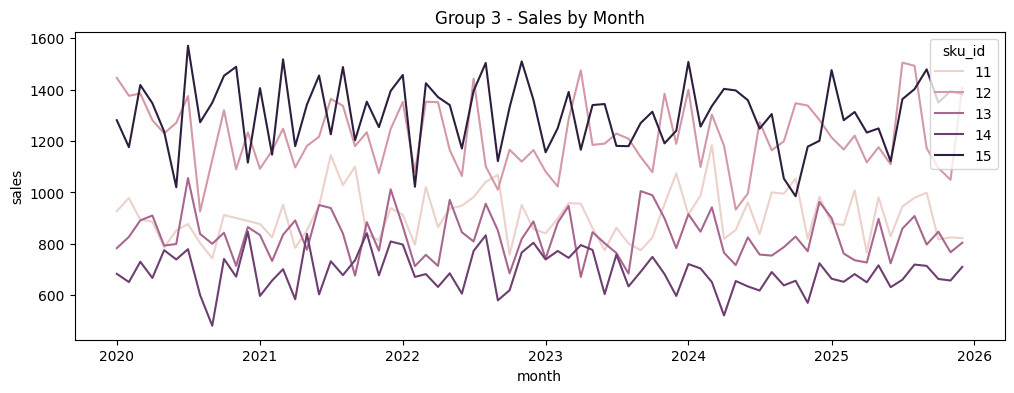

In [6]:

fig, ax = plt.subplots(figsize=(12,4))

df_month = (
    df_3
    .assign(month=df_3["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "sku_id"], as_index=False)["sales"]
    .sum()
)

sns.lineplot(
    data=df_month,
    x="month",
    y="sales",
    hue="sku_id"
)

plt.title('Group 3 - Sales by Month')
plt.show()

### Group 4 generator design

In [7]:
def generate_group4_skus(rng=None):
    """
    Generate sparse-demand SKUs with correlated demand occurrence patterns
    and one inventory policy per SKU.

    Returns
    -------
    pd.DataFrame
        Simulated daily SKU-level dataset from 2020 to 2025.
    """

    if rng is None:
        rng = np.random.default_rng(42)

    dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq="D")
    sku_ids = [16, 17, 18, 19, 20]

    demand_type = "sparse"
    category = "group_4_sparse"

    records = []

    shared_noise = rng.normal(loc=0, scale=1, size=len(dates))

    for sku_id in sku_ids:

        base_demand = int(rng.integers(5, 25))

        demand_probability = rng.uniform(0.15, 0.35)
        demand_size_mean = int(rng.integers(15, 60))

        lead_time = int(rng.integers(5, 12))

        expected_daily_demand = demand_probability * demand_size_mean

        safety_stock = int(
            expected_daily_demand * lead_time * rng.uniform(0.40, 0.80)
        )

        reorder_point = int(
            expected_daily_demand * lead_time + safety_stock
        )

        order_up_to_level = int(
            expected_daily_demand * (lead_time + 14) + safety_stock
        )

        initial_inventory = int(order_up_to_level * rng.uniform(0.80, 1.10))
        inventory = initial_inventory

        pending_orders = []

        for t, date in enumerate(dates):

            replenishment_qty = 0
            received_orders = []

            for arrival_date, qty in pending_orders:
                if arrival_date <= date:
                    replenishment_qty += qty
                    inventory += qty
                    received_orders.append((arrival_date, qty))

            pending_orders = [
                order for order in pending_orders
                if order not in received_orders
            ]

            correlated_probability = demand_probability + shared_noise[t] * 0.05
            correlated_probability = np.clip(correlated_probability, 0.01, 0.80)

            has_demand = rng.binomial(1, correlated_probability)

            if has_demand == 1:
                true_demand = rng.poisson(lam=demand_size_mean)
            else:
                true_demand = 0

            true_demand = max(0, int(true_demand))

            sales = min(true_demand, inventory)
            inventory -= sales

            stockout_flag = int(sales < true_demand)

            inventory_position = inventory + sum(qty for _, qty in pending_orders)

            if inventory_position <= reorder_point:
                order_qty = int(max(order_up_to_level - inventory_position, 0))
                arrival_date = date + pd.Timedelta(days=lead_time)
                pending_orders.append((arrival_date, order_qty))

            records.append({
                "date": date,
                "sku_id": sku_id,
                "category": category,
                "demand_type": demand_type,
                "sales": sales,
                "inventory_end": inventory,
                "replenishment_qty": replenishment_qty,
                "stockout_flag": stockout_flag,
                "base_demand": base_demand,
                "lead_time": lead_time,
                "safety_stock": safety_stock,
                "reorder_point": reorder_point,
                "order_up_to_level": order_up_to_level,
                "initial_inventory": initial_inventory
            })

    return pd.DataFrame(records)


df_4 = generate_group4_skus(rng)
df_4.head()

,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory
0,2020-01-01,16,group_4_sparse,sparse,0,154,0,0,19,7,29,74,164,154
1,2020-01-02,16,group_4_sparse,sparse,10,144,0,0,19,7,29,74,164,154
2,2020-01-03,16,group_4_sparse,sparse,0,144,0,0,19,7,29,74,164,154
3,2020-01-04,16,group_4_sparse,sparse,0,144,0,0,19,7,29,74,164,154
4,2020-01-05,16,group_4_sparse,sparse,0,144,0,0,19,7,29,74,164,154


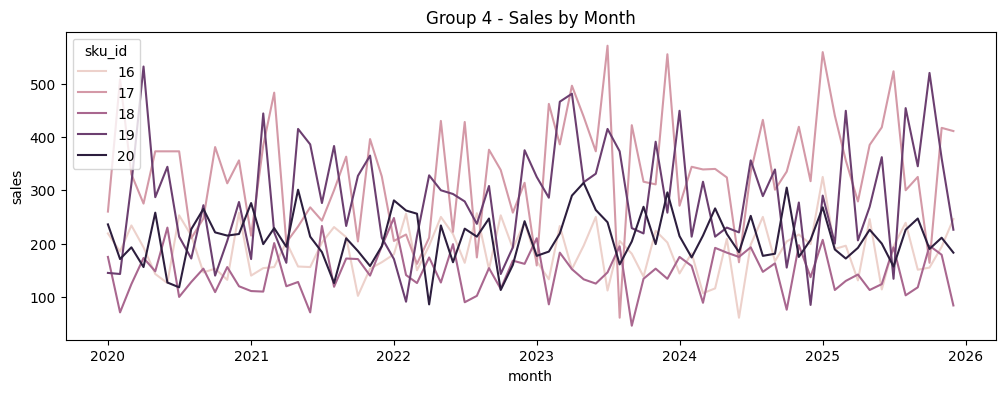

In [8]:

fig, ax = plt.subplots(figsize=(12,4))

df_month = (
    df_4
    .assign(month=df_4["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "sku_id"], as_index=False)["sales"]
    .sum()
)

sns.lineplot(
    data=df_month,
    x="month",
    y="sales",
    hue="sku_id"
)

plt.title('Group 4 - Sales by Month')
plt.show()

### Group and Save

In [9]:
df = pd.concat([df_1, df_2, df_3, df_4])
print(df.shape)
df.head()

(43840, 14)


,date,sku_id,category,demand_type,sales,inventory_end,replenishment_qty,stockout_flag,base_demand,lead_time,safety_stock,reorder_point,order_up_to_level,initial_inventory
0,2020-01-01,1,group_1_steady,steady,33,384,0,0,38,4,38,190,456,417
1,2020-01-02,1,group_1_steady,steady,31,353,0,0,38,4,38,190,456,417
2,2020-01-03,1,group_1_steady,steady,42,311,0,0,38,4,38,190,456,417
3,2020-01-04,1,group_1_steady,steady,43,268,0,0,38,4,38,190,456,417
4,2020-01-05,1,group_1_steady,steady,24,244,0,0,38,4,38,190,456,417


In [10]:
df.to_csv('../data/demand_stock.csv', index=False)